In [ ]:
#linear SVM model

In [ ]:
#checking cell: where is everything?
from google.colab import drive
drive.mount('/content/drive')

import os

#list what's inside your AI4_Data folder
base = '/content/drive/MyDrive'
print("Folders inside MyDrive:")
print(os.listdir(base))

print("\nFolders inside AI4_Data:")
print(os.listdir(base + '/AI4_Data'))

print("\nFolders inside AI4_Data/Processed:")
proc_path = base + '/AI4_Data/Processed'
if os.path.exists(proc_path):
    print(os.listdir(proc_path))
else:
    print("Processed folder does NOT exist")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Folders inside MyDrive:
['Colab Notebooks', 'TPS Pseudocode CW.gdoc', 'AI4_Data', 'JSONL_FilePractice.ipynb', 'LSDDA']

Folders inside AI4_Data:
['Raw', 'Processed', 'ByteEntropy_Temp', 'Notebooks', 'JobLibs']

Folders inside AI4_Data/Processed:
['tf0_processed.parquet', 'tf1_ByteEntropy.parquet', 'tf1_processed.parquet']


In [ ]:
#load tf1
import pandas as pd

TF1_PATH = '/content/drive/MyDrive/AI4_Data/Processed/tf1_processed.parquet'
tf1 = pd.read_parquet(TF1_PATH)

print("Loaded successfully!")
print("Shape:", tf1.shape)
tf1.head(3)

Loaded successfully!
Shape: (158158, 570)


,label,gen.size,gen.vsize,gen.has_debug,gen.exports,gen.imports,gen.has_relocations,gen.has_resources,gen.has_signature,gen.has_tls,...,byte.255,str.numstrings,str.avlength,str.printabledist,str.printables,str.entropy,str.paths,str.urls,str.registry,str.MZ
0,1,349811.0,28672.0,0.0,0.0,55.0,0.0,1.0,0.0,0.0,...,13644.0,3863.0,17.643541,NaN,68157.0,5.683164,6.0,22.0,0.0,7.0
1,-1,33776.0,36864.0,0.0,0.0,33.0,0.0,1.0,0.0,0.0,...,330.0,82.0,11.097561,NaN,910.0,5.454550,0.0,0.0,0.0,2.0
2,0,161280.0,184320.0,0.0,0.0,155.0,1.0,1.0,0.0,0.0,...,0.0,1452.0,15.486915,NaN,22487.0,5.668189,0.0,204.0,0.0,2.0


In [ ]:
#count real labels
tf1['label'].value_counts()

,count
label,
1,63713
0,52338
-1,42107


In [ ]:
#check percentage distribution
tf1['label'].value_counts(normalize=True)

,proportion
label,
1,0.402844
0,0.330922
-1,0.266234


In [ ]:
#drop unlabeled rows
tf1_clean = tf1[tf1['label'].isin([0, 1])].copy()

tf1_clean['label'].value_counts(), tf1_clean.shape

(label
 1    63713
 0    52338
 Name: count, dtype: int64,
 (116051, 570))

In [ ]:
#train/validation split
from sklearn.model_selection import train_test_split

#features and labels
x = tf1_clean.drop(columns=['label'])
y = tf1_clean['label']

#split data
X_train, X_val, y_train, y_val = train_test_split(
    x, y,
    test_size=0.2,    #20% of data will go to validation
    stratify=y,       #label proportions are kept equal
    random_state=42   #reproducibilty
)

print("Train shape:", X_train.shape)
print("Validation shape:", X_val.shape)

print("\nLabel Distribution in training set:")
print(y_train.value_counts(normalize=True))

print("\nLabel Distribution in validation set:")
print(y_val.value_counts(normalize=True))

Train shape: (92840, 569)
Validation shape: (23211, 569)

Label Distribution in training set:
label
1    0.549009
0    0.450991
Name: proportion, dtype: float64

Label Distribution in validation set:
label
1    0.549007
0    0.450993
Name: proportion, dtype: float64


In [ ]:
#drop columns that are entirely missing (all NaN) in the training set
all_nan_cols = X_train.columns[X_train.isna().all()]
print("Dropping all-NaN columns:", list(all_nan_cols))

X_train = X_train.drop(columns=all_nan_cols)
X_val   = X_val.drop(columns=all_nan_cols)

Dropping all-NaN columns: ['hdr.coff.machine', 'hdr.coff.characteristics', 'hdr.optional.subsystem', 'hdr.optional.dll_characteristics', 'hdr.optional.magic', 'sect.sections', 'str.printabledist']


In [ ]:
#Linear SVM (hinge loss) trained with SGD for scalability on large datasets
#same preprocessing steps as LR:
# 1) median imputation, 2) standard scaling, 3) linear SVM decision rule

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import SGDClassifier

svm_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("svm", SGDClassifier(
        loss="hinge",        #linear SVM objective
        alpha=0.0001,        #regularisation (default baseline)
        max_iter=2000,       #more iterations for stability
        tol=1e-3,            #stopping tolerance
        random_state=42
    ))
])

#fit the model on the training set
svm_pipeline.fit(X_train, y_train)

Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler()),
                ('svm', SGDClassifier(max_iter=2000, random_state=42))])

In [ ]:
#predict class labels on the validation set
y_pred_svm = svm_pipeline.predict(X_val)

#fet decision scores for ROC / PR curves
y_score_svm = svm_pipeline.decision_function(X_val)

In [ ]:
#same metrics as used for LR & RF
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score,
    precision_recall_curve, roc_curve, auc
)

#core classification metrics
svm_accuracy  = accuracy_score(y_val, y_pred_svm)
svm_precision = precision_score(y_val, y_pred_svm)
svm_recall    = recall_score(y_val, y_pred_svm)
svm_f1        = f1_score(y_val, y_pred_svm)

#AUC metrics using decision scores
svm_roc_auc = roc_auc_score(y_val, y_score_svm)

precision_curve, recall_curve, _ = precision_recall_curve(y_val, y_score_svm)
svm_pr_auc = auc(recall_curve, precision_curve)

print("Linear SVM (SGD hinge) Results")
print(f"Accuracy:  {svm_accuracy:.4f}")
print(f"Precision: {svm_precision:.4f}")
print(f"Recall:    {svm_recall:.4f}")
print(f"F1-score:  {svm_f1:.4f}")
print(f"ROC-AUC:   {svm_roc_auc:.4f}")
print(f"PR-AUC:    {svm_pr_auc:.4f}")

Linear SVM (SGD hinge) Results
Accuracy:  0.7270
Precision: 0.7603
Recall:    0.7341
F1-score:  0.7470
ROC-AUC:   0.7829
PR-AUC:    0.7979


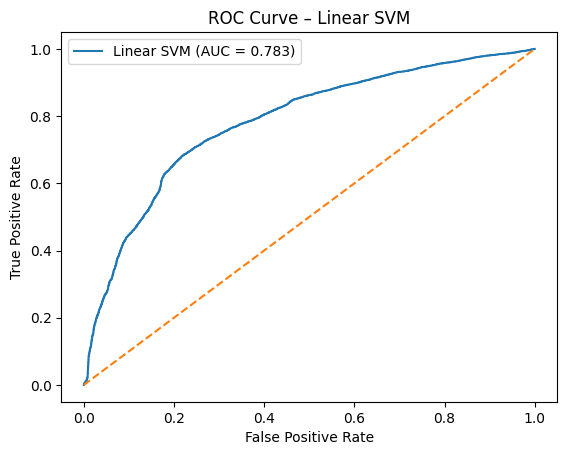

In [ ]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

#compute ROC curve
fpr, tpr, _ = roc_curve(y_val, y_score_svm)

#plot ROC
plt.figure()
plt.plot(fpr, tpr, label=f"Linear SVM (AUC = {svm_roc_auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – Linear SVM")
plt.legend()
plt.show()

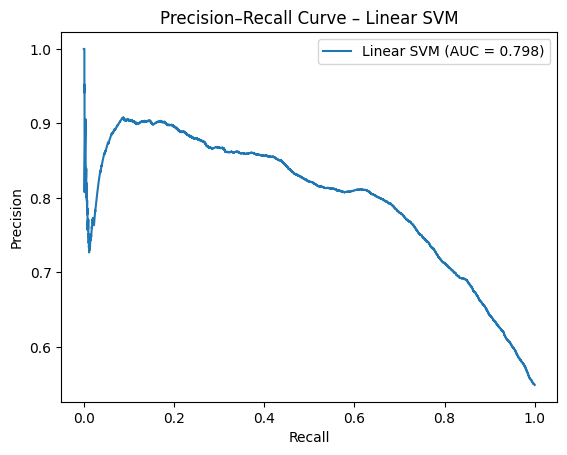

In [ ]:
from sklearn.metrics import precision_recall_curve, auc

#compute PR curve
precision_curve, recall_curve, _ = precision_recall_curve(y_val, y_score_svm)

#plot PR
plt.figure()
plt.plot(recall_curve, precision_curve, label=f"Linear SVM (AUC = {svm_pr_auc:.3f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve – Linear SVM")
plt.legend()
plt.show()

In [ ]:
from pathlib import Path

JOBLIBS_DIR = Path("/content/drive/MyDrive/AI4_Data/JobLibs")
JOBLIBS_DIR.mkdir(parents=True, exist_ok=True)

print("Saving to:", JOBLIBS_DIR)

Saving to: /content/drive/MyDrive/AI4_Data/JobLibs


In [ ]:
import joblib

joblib.dump(svm_pipeline, JOBLIBS_DIR / "svm_baseline_model.joblib")
print("Saved:", JOBLIBS_DIR / "svm_baseline_model.joblib")

Saved: /content/drive/MyDrive/AI4_Data/JobLibs/svm_baseline_model.joblib
